In [15]:
#!pip install plotnine

In [2]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
from plotnine import ggplot, aes, geom_point, facet_grid, labs, scale_y_continuous, labeller, as_labeller
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [3]:
# read in data
data = pd.read_csv("tqc_clean.csv")
data = data[['months', 'act0', 'act1', 'CPUE', 'biomass']]
data.head()

,months,act0,act1,CPUE,biomass
0,3,-0.911334,-0.843671,-1.0,-1.0
1,4,-0.964028,-0.703425,-1.0,-1.0
2,5,-0.964028,-0.904936,-1.0,-1.0
3,6,-0.884734,-0.851039,-1.0,-1.0
4,7,-0.839049,-0.761919,-1.0,-1.0


In [4]:
# remove anomolous biomass data
data = data[(data['biomass'] != -1) & (data['biomass'] <= -0.2)]

In [5]:
# set K range and loop through months and actions to find best k and cluster data
K_range = range(2, 7)
months = data['months'].unique()
actions = ['act0', 'act1']
all_centroids = []
all_labeled = []

for month in months:
    data_month = data[data['months'] == month].drop(columns=['months'])
    
    for action in actions:
        other_action = 'act1' if action == 'act0' else 'act0'
        X = data_month.drop(columns=[other_action])
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        scores = []
        for k in K_range:
            km = KMeans(n_clusters=k, n_init=30, random_state=42).fit(X_scaled)
            scores.append(silhouette_score(X_scaled, km.labels_))
        
        best_k = K_range[np.argmax(scores)]
        kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=42).fit(X_scaled)
        
        # build labeled chunk
        chunk = X.copy().reset_index(drop=True)
        chunk['month'] = month
        chunk['action'] = action
        chunk['cluster'] = kmeans.labels_
        all_labeled.append(chunk)
        
        # store centroids
        centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
        centroids_df = pd.DataFrame(centroids_original, columns=X.columns)
        centroids_df['month'] = month
        centroids_df['action'] = action
        centroids_df['cluster'] = range(best_k)
        all_centroids.append(centroids_df)

labeled = pd.concat(all_labeled, ignore_index=True)
centroids = pd.concat(all_centroids, ignore_index=True)



In [7]:
labeled.to_csv("labeled.csv", index=False)
centroids.to_csv("centroids.csv", index=False)


In [ ]:
def find_closest_actions(CPUE, biomass, month, centroids):
    results = {}
    for action in ['act0', 'act1']:
        subset = centroids[(centroids['month'] == month) & (centroids['action'] == action)].copy()
        subset['dist'] = ((subset['CPUE'] - CPUE)**2 + (subset['biomass'] - biomass)**2)**0.5
        closest = subset.loc[subset['dist'].idxmin()]
        results[action] = closest[action]
    return results['act0'], results['act1']


class CentroidAgent:
    """Agent that selects actions by finding the nearest centroid for the current observation.

    Expects observations of the form {"crabs": np.array([CPUE, biomass]), "months": month},
    i.e. observation_type='count-biomass-time'.
    """
    def __init__(self, centroids: pd.DataFrame, env):
        self.centroids = centroids
        self.env = env

    def predict(self, observation, **kwargs):
        CPUE = float(observation["crabs"][0])
        biomass = float(observation["crabs"][1])
        month = int(observation["months"])
        act0, act1 = find_closest_actions(CPUE, biomass, month, self.centroids)
        return np.array([act0, act1], dtype=np.float32), {}

# example usage:
# centroid_agent = CentroidAgent(centroids=centroids, env=evalEnv)
# centroid_plot_agent = plot_agent(env_sim_df=None,
#                                  agent_name='centroid_agent',
#                                  env=evalEnv,
#                                  agent=centroid_agent,
#                                  save_dir='.')

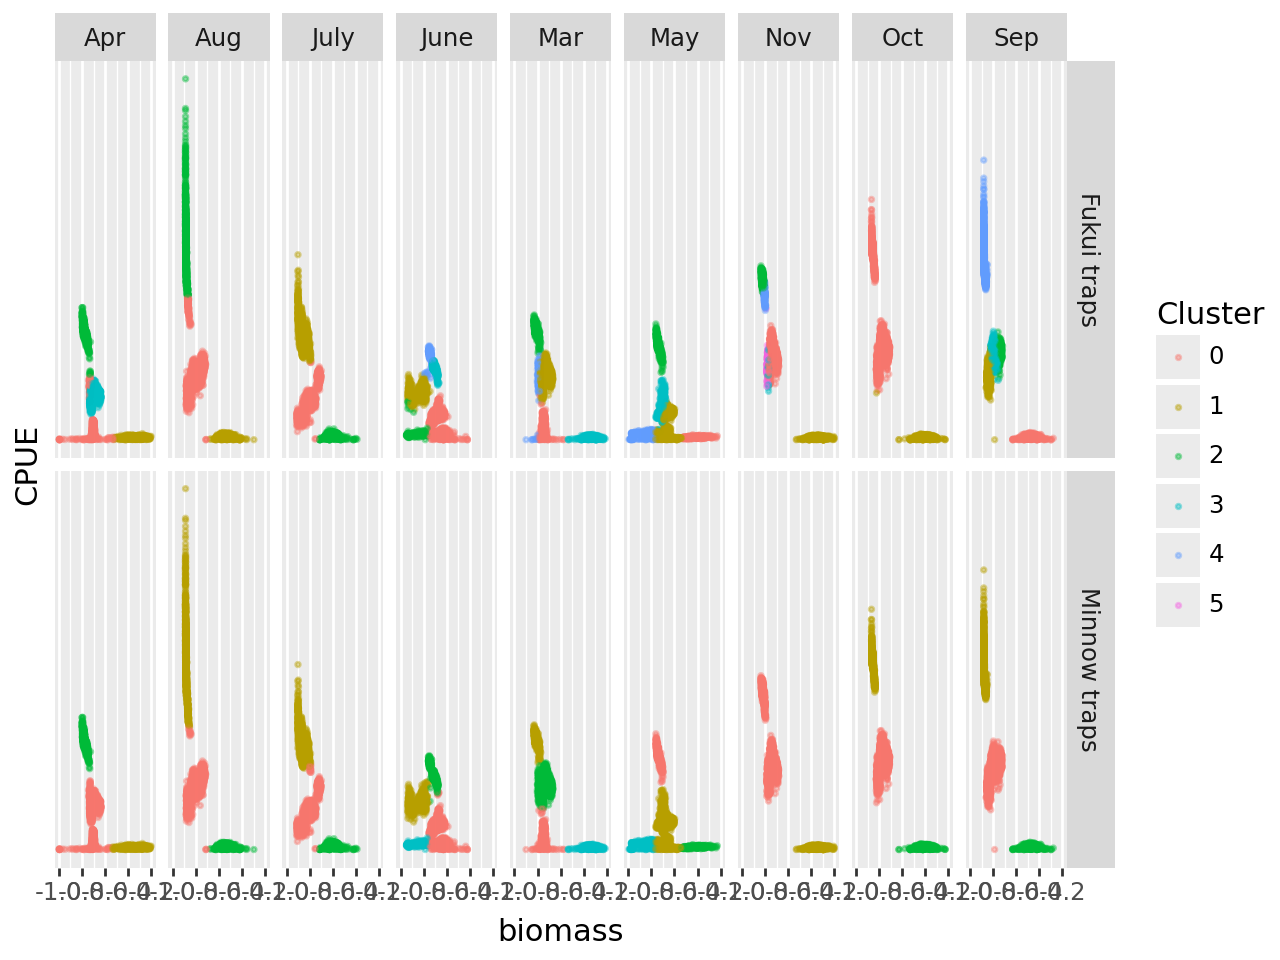

In [ ]:
month_names = {"3": "Mar", "4": "Apr", "5": "May",
               "6": "June", "7": "July", "8": "Aug",
               "9": "Sep", "10": "Oct", "11": "Nov"}
action_names = {"act0": "Minnow traps", "act1": "Fukui traps"}

plot_data = labeled.copy()
plot_data['month'] = plot_data['month'].astype(str).map(month_names)
plot_data['action'] = plot_data['action'].map(action_names)

(
    ggplot(plot_data, aes(x='biomass', y='CPUE', color='factor(cluster)'))
    + geom_point(alpha=0.4, size=0.5)
    + facet_grid('action ~ month')
    + labs(color='Cluster')
    + scale_y_continuous(breaks=[0, 10, 20])
)

In [6]:
centroids

,act0,CPUE,biomass,month,action,cluster,act1
0,-0.964028,-0.967734,-0.741455,5,act0,0,NaN
1,-0.964028,-0.991361,-0.665787,5,act0,1,NaN
2,-0.964028,-0.999112,-0.401977,5,act0,2,NaN
3,-0.964028,-0.998416,-0.888258,5,act0,3,NaN
4,NaN,-0.999106,-0.399720,5,act1,0,-0.842600
...,...,...,...,...,...,...,...
62,-0.964028,-0.963089,-0.779592,4,act0,2,NaN
63,NaN,-0.994812,-0.712463,4,act1,0,-0.545474
64,NaN,-0.999201,-0.327071,4,act1,1,-0.582316
65,NaN,-0.963222,-0.779134,4,act1,2,-0.427785


In [10]:
max(centroids['act0'])

0.7765293592878563

In [11]:
min(centroids['act0'])

-0.9640276